### DBSCAN - Desity based clusturing of application with noice

- DBSCAN is a clustering algorithm for machine learning that groups together densely packed data points, marking points in low-density regions as "noise"

- The algorithm uses two main parameters, epsilon (a radius) and min_samples (the minimum number of points required to form a dense region), to classify points as core, border, or noise points

# Importing Depnedencies

In [79]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
X, Y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [81]:
df = pd.DataFrame(X, columns=['Featur_1', 'Feature_2'])

In [82]:
print(X)

[[ 0.83058575 -0.44773257]
 [ 0.70167816  0.81691843]
 [ 1.02208004 -0.49257102]
 [-0.31676455  0.95343844]
 [ 0.29322631  1.05718523]
 [ 1.25490304 -0.48343549]
 [ 1.05385133 -0.44269047]
 [ 0.03137971  1.05301203]
 [ 0.62054473  0.71309598]
 [ 1.7876566  -0.14295878]
 [ 0.99907493  0.09180641]
 [-0.70723041  0.57499903]
 [ 1.46479643 -0.47111862]
 [ 0.42712245  0.83103216]
 [ 1.05341942 -0.50102941]
 [ 1.19597671 -0.49472393]
 [ 1.99422286  0.42426007]
 [ 0.93175527  0.39426183]
 [ 0.41104275 -0.33348189]
 [ 1.49073255 -0.38560138]
 [ 1.97517181  0.35930615]
 [ 2.0470942   0.41068552]
 [-0.00592133  0.14862165]
 [ 0.82592072 -0.42998975]
 [ 0.54309448  0.75144817]
 [ 1.8709548   0.20141701]
 [ 1.9224317   0.43263225]
 [-0.86765136  0.45505598]
 [ 0.28216036  1.05760226]
 [ 0.46830301 -0.37297875]
 [ 1.96459943  0.16156525]
 [ 0.46109717 -0.37085997]
 [ 1.82618233 -0.15729667]
 [-0.56993375  0.82268505]
 [ 0.98676076  0.08440511]
 [ 0.47472789 -0.43386468]
 [ 1.34258244 -0.40280118]
 

In [83]:
scalar = StandardScaler()

In [84]:
X_scalar = scalar.fit_transform(X)

In [85]:
print(X)

[[ 0.83058575 -0.44773257]
 [ 0.70167816  0.81691843]
 [ 1.02208004 -0.49257102]
 [-0.31676455  0.95343844]
 [ 0.29322631  1.05718523]
 [ 1.25490304 -0.48343549]
 [ 1.05385133 -0.44269047]
 [ 0.03137971  1.05301203]
 [ 0.62054473  0.71309598]
 [ 1.7876566  -0.14295878]
 [ 0.99907493  0.09180641]
 [-0.70723041  0.57499903]
 [ 1.46479643 -0.47111862]
 [ 0.42712245  0.83103216]
 [ 1.05341942 -0.50102941]
 [ 1.19597671 -0.49472393]
 [ 1.99422286  0.42426007]
 [ 0.93175527  0.39426183]
 [ 0.41104275 -0.33348189]
 [ 1.49073255 -0.38560138]
 [ 1.97517181  0.35930615]
 [ 2.0470942   0.41068552]
 [-0.00592133  0.14862165]
 [ 0.82592072 -0.42998975]
 [ 0.54309448  0.75144817]
 [ 1.8709548   0.20141701]
 [ 1.9224317   0.43263225]
 [-0.86765136  0.45505598]
 [ 0.28216036  1.05760226]
 [ 0.46830301 -0.37297875]
 [ 1.96459943  0.16156525]
 [ 0.46109717 -0.37085997]
 [ 1.82618233 -0.15729667]
 [-0.56993375  0.82268505]
 [ 0.98676076  0.08440511]
 [ 0.47472789 -0.43386468]
 [ 1.34258244 -0.40280118]
 

In [86]:
k_means = KMeans(n_clusters=3, random_state=42)
kmeans_labels = k_means.fit_predict(X_scalar)

In [87]:
df['kmeans_cluster'] = kmeans_labels

In [88]:
df.head()

,Featur_1,Feature_2,kmeans_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,2
4,0.293226,1.057185,0


<Axes: xlabel='Featur_1', ylabel='Feature_2'>

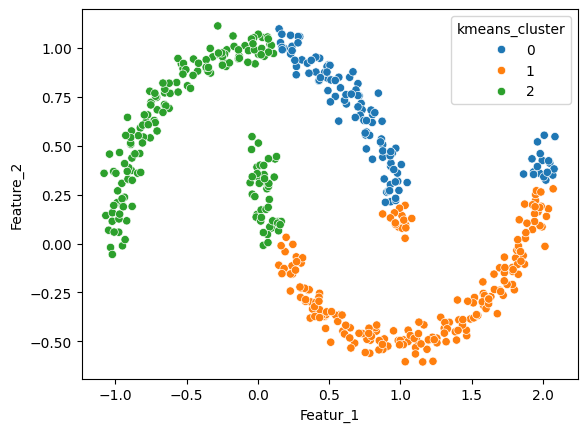

In [89]:
sns.scatterplot(x=df['Featur_1'], y = df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

- On Non circular data K Mean clusturing have issues

# DBSCAN

In [90]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scalar)

In [91]:
df['dbscan_clustur'] = dbscan_labels

In [92]:
df.head()

,Featur_1,Feature_2,kmeans_cluster,dbscan_clustur
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,2,1
4,0.293226,1.057185,0,1


<Axes: xlabel='Featur_1', ylabel='Feature_2'>

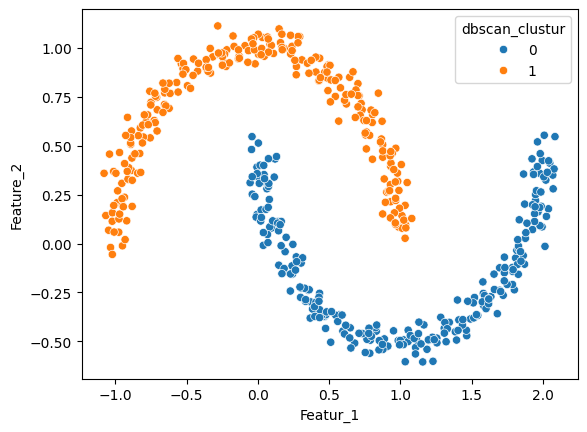

In [93]:
sns.scatterplot(x=df['Featur_1'], y = df['Feature_2'], hue=df['dbscan_clustur'], palette='tab10')

Unlike k-means, where you directly set the number of clusters (k), DBSCAN does not take the number of clusters as an input. Instead, DBSCAN discovers clusters automatically based on density.